### Differential gene expression and pathway analysis for Glioblastoma tumors vs models and generation of Extended Data Figure 6b

This notebook provides an example for **Extended Data Figure 6b**. By changing the value of `cohort` to "PAAD" or "COAD" it enables the generation of Extended Data Figures 7c, 8a.     

Setup user-defined parameters. Specify the `cohort` to be analyzed to be either "GBM" (default), "PDAC" or "COAD".
Provide the full path to "HCMI_snRNAseq_data_metadata" as `Work_dir` and the full path to the current GitHub repository as `Code_dir`.

In [1]:
cohort = "GBM" # either "GBM", "PDAC" or "COAD"

Work_dir = "/groups/ac2248_gp/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" # parent directory for input data
Code_dir = "/groups/ac2248_gp/lz2841/ColumbiaProjects/HCMI-single-nuclei/" # path to GitHub folder

Other settings include the number of DEGs to show in heatmap (see below), whether to display only significant pathway, the number of top pathways to visualize and the threshold of significance.

In [2]:
n_DEG = 20 # number of DEGs to show
only_significant_pathways = True
top_pathways = 10
pathway_alpha = 0.05 # alpha for pathway significance 

Paths to marker directory and demultiplexed input data are automatically specified below.

In [3]:
filtering_level_vcf = "filtered_01"  # use data from demultiplexing based on MAF>0.1%
sample_assignment = "best_gt_thresh" # according to manuscript methods

# Postprocessing input filtering_level_vcf
if filtering_level_vcf == "no_filtered":
    filtering_level_vcf = ""
elif filtering_level_vcf == "filtered":
    filtering_level_vcf = "-filtered"
elif filtering_level_vcf == "filtered_01":
    filtering_level_vcf = "-filtered-01"
else:
    print("Unknown value provided for filtering_level_vcf")


markers_dir = f"{Code_dir}/markers/" # path to directory collecting gene expression markers

Specify cases for each cohort.

In [4]:
if cohort == "GBM":
    cases=["HCM-BROD-0416-C71", "HCM-BROD-0415-C71", "HCM-BROD-0012-C71", "HCM-BROD-0199-C71", "HCM-BROD-0028-C71",  "HCM-BROD-0213-C71", "HCM-BROD-0002-C71"]
elif cohort == "PDAC":
    cases=["HCM-CSHL-0073-C25", "HCM-CSHL-0078-C25", "HCM-CSHL-0089-C25", "HCM-BROD-0110-C25"]
elif cohort == "COAD":
    cases=["HCM-CSHL-0143-C20", "HCM-CSHL-0322-C20", "HCM-BROD-0001-C18"]
else:
    print(f"Cases for {cohort} not available.")

Import packages

In [5]:
import sys
import scanpy as sc
import numpy as np 
from numpy import nanmedian, NaN
import pandas as pd
import os 
from matplotlib import rc_context
import seaborn as sns
import matplotlib.pyplot as plt
import pyviper
sc.settings.verbosity = 0
sc.logging.print_header()
sc.settings.set_figure_params(frameon=False, dpi=100, facecolor="white")
from matplotlib.backends.backend_pdf import PdfPages
import hdf5plugin
import anndata
import gc
from contextlib import contextmanager
import warnings
warnings.simplefilter("ignore", category=UserWarning)
from scipy.sparse import issparse
import re
import math
sys.path.append(f'{Code_dir}/funcs/')
from processing_funcs import * # some custom functions

# Specify default font family and fontsize
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7

2025-08-25 13:26:28.875481: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-25 13:26:28.886620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756142788.899114  602919 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756142788.902969  602919 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756142788.913299  602919 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.3 scipy==1.12.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13


Define a function to subset for putative malignant clusters.

In [6]:
def process_clusters(clusters_putative_malignant):
    # Extract the value from the Series (assuming a single element in the Series)
    cluster_value = clusters_putative_malignant.values[0]
    
    # Check if the value is "all"
    if isinstance(cluster_value, str) and cluster_value.lower() == "all":
        return cluster_value
    # If it's a comma-separated string, split it into a list of integers
    elif isinstance(cluster_value, str) and "," in cluster_value:
        return [int(i) for i in cluster_value.split(",")]
    # If it's a single integer, wrap it in a list
    else:
        return [int(cluster_value)]

Load snRNA-seq metadata.

In [7]:
snRNAseq_metadata_path = f"{Code_dir}Matched Model_Tumor for Sequencing.xlsx"
snRNAseq_metadata = pd.read_excel(snRNAseq_metadata_path, sheet_name="Samplesheet_for_Analysis")

Load snRNA-seq data and subset for putative malignant cells only.

In [8]:
adata_samples = {}  # initialize dictionary collecting AnnData object
samples_metadata_path = f"{Work_dir}/metadata/" # path to gene expression metadata
for case in cases:

    print(f"Case: {case}")

    case_metadata = snRNAseq_metadata[snRNAseq_metadata["Case ID"] == case] # subset for the Case ID being loaded
    
    # Automatically define sample names and paths to data
    samples = [f'{case_metadata.loc[idx,"Multiplex (GEM) ID"]}_{case}' for idx in case_metadata.index] # samples names
    file_paths = {ID: f"{Work_dir}demultiplexed_samples_{sample_assignment}{filtering_level_vcf}/{ID}_gt.h5ad" for ID in samples} # path to data
    
    # Load snRNA-seq metadata
    for sample, path in file_paths.items():
        # Load gene expression data and include it into AnnData object
        print('Loading ID',sample,end=' ')
        adata_samples[sample] = sc.read_h5ad(filename=path) # adata
        adata_samples[sample].var_names_make_unique()
        adata_samples[sample].obs["Sample Type"] = adata_samples[sample].obs["Sample Type"].str.rstrip() # strip spaces from Sample Type
        print(': AnnData of dimensions',adata_samples[sample].shape)

        # Subset for only the cells that previously passed QC and then only for putative malignant cells
        sample_metadata_path = f"{samples_metadata_path}{sample}-metadata.tsv"
        sample_infercnv_path = f"{samples_metadata_path}{sample}-chrs-infercnv.tsv"
        clusters_putative_malignant = case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Putative malignant clusters"]

        sample_metadata = pd.read_csv(sample_metadata_path, sep="\t")
        sample_infercnv = pd.read_csv(sample_infercnv_path, sep="\t")


        columns_to_add_metadata = sample_metadata.columns.difference(adata_samples[sample].obs.columns)
        sample_metadata = sample_metadata[columns_to_add_metadata]

        # subset for cells retained in the metadata table
        print("Subsetting only for putative malignant cells")
        cohort = list(case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Cohort"])[0]

        adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs.index.isin(sample_metadata["barcode"])]
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata, left_on='barcode', right_on="barcode", how='left') # attach metadata
        # subset of only putative malignant cells
        clusters_putative_malignant = process_clusters(clusters_putative_malignant)
        if clusters_putative_malignant != "all":
            adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["clusters"].isin(clusters_putative_malignant)]

            if cohort == "PDAC":
                adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["singler_BpE_cg"] == "Epithelial cells"]
            
            if cohort == "COAD":
                adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["singler_BpE_cg"].isin(["Epithelial cells", "Neurons"])]

        adata_samples[sample].obs.set_index("barcode", inplace=True) # set indewx
        sc.pp.calculate_qc_metrics(adata_samples[sample], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

    # Gene selection
    gene_names = adata_samples[sample].var_names # assume gene names are the same across all samples
    gene_counts = np.zeros(len(gene_names))
    # Iterate over each sample and accumulate the counts
    for sample, adata in adata_samples.items():
        if issparse(adata.X):
            gene_counts += np.array(adata.X.sum(axis=0)).flatten()
        else:
            gene_counts += np.sum(adata.X, axis=0)
    # Convert to DataFrame for better readability
    gene_counts_df = pd.DataFrame(data=gene_counts, index=gene_names, columns=['Total_Counts'])
    genes_retain = gene_counts_df[gene_counts_df["Total_Counts"] >= 10].index.to_list() # genes to retain 
    genes_retain = [str(gene) for gene in genes_retain]

    del gene_names, gene_counts, gene_counts_df
    gc.collect()

Case: HCM-BROD-0416-C71
Loading ID AG006_HCM-BROD-0416-C71 : AnnData of dimensions (8267, 38606)
Subsetting only for putative malignant cells
Loading ID AG007_HCM-BROD-0416-C71 : AnnData of dimensions (6130, 38606)
Subsetting only for putative malignant cells
Case: HCM-BROD-0415-C71
Loading ID AA016_HCM-BROD-0415-C71 : AnnData of dimensions (10615, 38606)
Subsetting only for putative malignant cells
Loading ID AA017_HCM-BROD-0415-C71 : AnnData of dimensions (4453, 38606)
Subsetting only for putative malignant cells
Case: HCM-BROD-0012-C71
Loading ID AA014_HCM-BROD-0012-C71 : AnnData of dimensions (8563, 38606)
Subsetting only for putative malignant cells
Loading ID AA015_HCM-BROD-0012-C71 : AnnData of dimensions (18738, 38606)
Subsetting only for putative malignant cells
Case: HCM-BROD-0199-C71
Loading ID AA014_HCM-BROD-0199-C71 : AnnData of dimensions (6035, 38606)
Subsetting only for putative malignant cells
Loading ID AA015_HCM-BROD-0199-C71 : AnnData of dimensions (2664, 38606)
Sub

Perform gene filtering and concatenate samples.

In [9]:
# Actual gene filtering
samples = list(adata_samples.keys())
for sample in samples:
    print(f"Gene filtering for {sample}")
    adata_samples[sample] = adata_samples[sample][:, genes_retain]

# Samples concatenation
adata_all = sc.concat(list(adata_samples.values()), axis = 0, join = 'outer') # integrate counts
adata_all.obs["Tumor or Model"] = adata_all.obs["Tumor or Model"].cat.reorder_categories(['T', 'M'], ordered=True) # order T and M categories
adata_all.layers["counts"] = adata_all.X.copy()
adata_all.obs["Sample ID snRNAseq"] = pd.Categorical(adata_all.obs["Sample ID snRNAseq"], categories=samples, ordered=True) # order categories according to the samples list

del adata_samples
gc.collect()

Gene filtering for AG006_HCM-BROD-0416-C71
Gene filtering for AG007_HCM-BROD-0416-C71
Gene filtering for AA016_HCM-BROD-0415-C71
Gene filtering for AA017_HCM-BROD-0415-C71
Gene filtering for AA014_HCM-BROD-0012-C71
Gene filtering for AA015_HCM-BROD-0012-C71
Gene filtering for AA014_HCM-BROD-0199-C71
Gene filtering for AA015_HCM-BROD-0199-C71
Gene filtering for AG004_HCM-BROD-0028-C71
Gene filtering for AG005_HCM-BROD-0028-C71
Gene filtering for AG006_HCM-BROD-0213-C71
Gene filtering for AG007_HCM-BROD-0213-C71
Gene filtering for AA016_HCM-BROD-0002-C71
Gene filtering for AA017_HCM-BROD-0002-C71


32080

Data preprocessing: perform log normalization 

In [10]:
print("Normalizing (data) and log-transforming (logdata)")
sc.pp.normalize_total(adata_all, target_sum=1e4, inplace=True) # normalize data 
sc.pp.log1p(adata_all) # logdata - log-normalization
adata_all.layers["logdata"] = adata_all.X.copy() # store logdata in the corresponding layer  

Normalizing (data) and log-transforming (logdata)


#### Find differentially expressed genes (DEG) in Tumor vs Models comparison

First, filter ribosomal and mitochondrial genes and specify graphic parameters.

In [11]:
ribo_genes = list(pd.read_csv(f"{markers_dir}KEGG_ribosome.csv").columns)
mito_genes = list(pd.read_csv(f"{markers_dir}mt-genes.csv")["hum.symb"])
ribo_mito_genes = ribo_genes + mito_genes
adata_all = adata_all[:,~adata_all.var.index.isin(ribo_mito_genes)] # remove ribosomal and mitochondrial genes from analysis

adata_all.uns["Tumor or Model_colors"] = ['#8dd3c7', '#ffffb3'] # color by Tumor and Model

Compute DEGs in tumor vs model using Wilcoxon Rank Sum test. Display top 'n_DEG' per group. Extract DEGs for further analyses

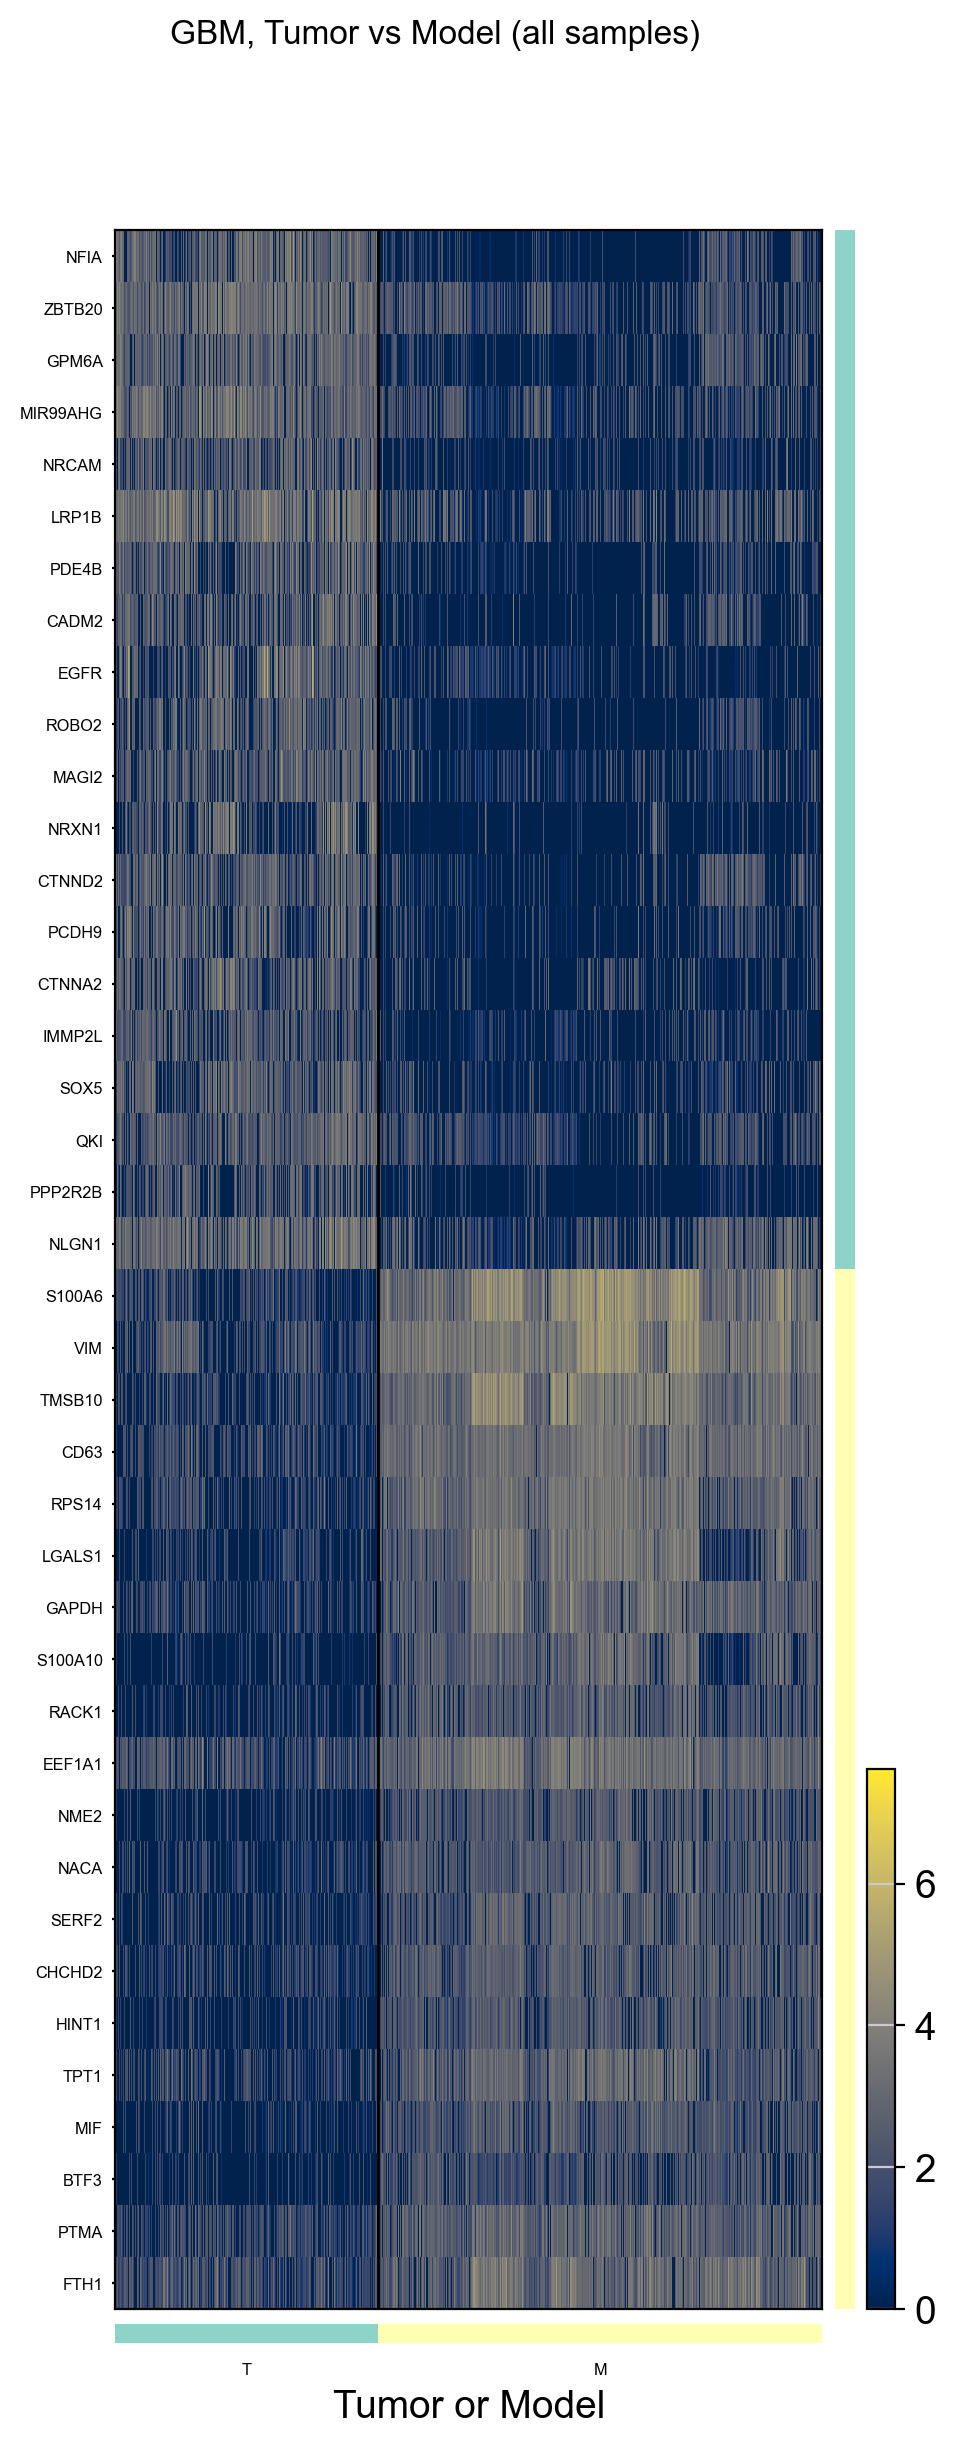

In [12]:
sc.tl.rank_genes_groups(adata_all, groupby="Tumor or Model", method="wilcoxon", layer="logdata") # Run Wilcoxon

# Display heatmap - all tumor vs models
title = f"{cohort}, Tumor vs Model (all samples)"
with rc_context():
    figsize = (5, len(samples))
    sc.pl.rank_genes_groups_heatmap(adata_all,  cmap="cividis", n_genes=n_DEG, layer="logdata",swap_axes=True, var_group_rotation=90, dendrogram=False, show_gene_labels=True, show=False, figsize=figsize)
    plt.suptitle(title, fontsize=12)
    plt.show()


# Extract DEG signatures for further analyses
DEG_T_vs_M = adata_all.uns["rank_genes_groups"]
DEG_T_vs_M_df = sc.get.rank_genes_groups_df(adata_all, group=None)

# Generate an AnnData object from the dedf
adata_lfc = create_anndata_from_lfc(DEG_T_vs_M_df)

### Perform Pathway Analysis
Load gene sets for pathway analysis.

In [13]:
# MSigDB
hallmarks_MSigDB = pyviper.load.msigdb_regulon('h') # load hallmark of cancer MSigDB as an interactome
hallmarks_MSigDB.net_table["regulator"] = hallmarks_MSigDB.net_table["regulator"].str.replace("HALLMARK_","") # remove HALLMARK_ from text
hallmarks_MSigDB.net_table["regulator"] = hallmarks_MSigDB.net_table["regulator"].str.replace("_"," ") # remove _ from text

# Additional signatures for GBM -> convert to Interactome for pyVIPER
if cohort == "GBM":
    # Wang signature
    Wang_signature = pd.read_excel(f"{markers_dir}bulk-GBM-PN-MES-Classical.xlsx", sheet_name="Subtype Signatures  Processed")
    Wang_signature = pd.melt(Wang_signature, var_name='regulator', value_name='target').dropna(subset=['target'])
    Wang_signature["mor"] = 1
    Wang_signature["likelihood"] = 1
    Wang_signature["regulator"] = Wang_signature["regulator"].str.upper()

    # Suva' markers
    Suva_gene_sets = pd.read_excel(f"{markers_dir}GBM-markers.xlsx", sheet_name="S2_Neftel") 
    Suva_gene_sets.drop(columns=['G1/S', 'G2/M'], inplace=True)
    Suva_gene_sets.columns = Suva_gene_sets.columns.str.replace("-like", "", regex=False)
    
    Suva_network = pd.melt(Suva_gene_sets, var_name='regulator', value_name='target').dropna(subset=['target'])
    Suva_network["mor"] = 1
    Suva_network["likelihood"] = 1
    Suva_network = Suva_network.drop_duplicates(subset=['regulator', 'target'])
    
    hallmarks_MSigDB.net_table = pd.concat([hallmarks_MSigDB.net_table, Wang_signature, Suva_network], axis=0)
    

Perform pathway analysis.

In [14]:
print(f"Performing pathway enrichment analysis based on DEG signature. Convert to P value and compute -log10(FDR)")
path_enr_DEG = pyviper.tl.path_enr(adata_lfc, pathway_interactome=hallmarks_MSigDB, enrichment="narnea", verbose="False", store_input_data=False) # compute enrichment
pyviper.pp.nes_to_pval(path_enr_DEG, lower_tail=False, adjust=True, key_added="pval") # adjust for multiple test

path_enr_DEG.layers["mlog10"] = -1 * np.log10(path_enr_DEG.layers["pval"]) # compute -log10(FDR)

# store pathway NES also in layer "nes" of the AnnData object
path_enr_DEG.layers["nes"] = path_enr_DEG.X.copy()
# add Tumor or Model .obs annotation to .index
path_enr_DEG.obs["Tumor or Model"] = path_enr_DEG.obs.index

Performing pathway enrichment analysis based on DEG signature. Convert to P value and compute -log10(FDR)
Removed 373 targets.
Preparing the association scores
Computing regulons enrichment with NaRnEa
reordering genes
Calculating DES...
Calculating UES...
Calculating NES...
Calculating PES...


/users/lz2841/.conda/envs/scRNA-seq/lib/python3.11/site-packages/pyviper/NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)


Select top pathways (e.g., based on threshold of significance)

In [15]:
# significant pathways 
path_enr_DEG.X = path_enr_DEG.layers["pval"]
significant_pathways = (path_enr_DEG.to_df() < pathway_alpha).any(axis=0)
significant_pathways = significant_pathways[significant_pathways].index

Display top activated pathways (Normalized Enrichment Score and -log10(FDR)) in tumors and models. The -log10(FDR) visualization corresponds to **Extended Data Figure 6b** for Glioblastoma.

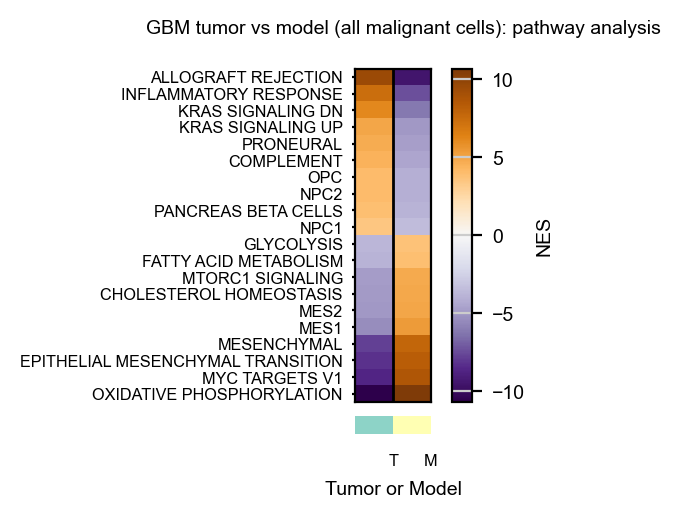

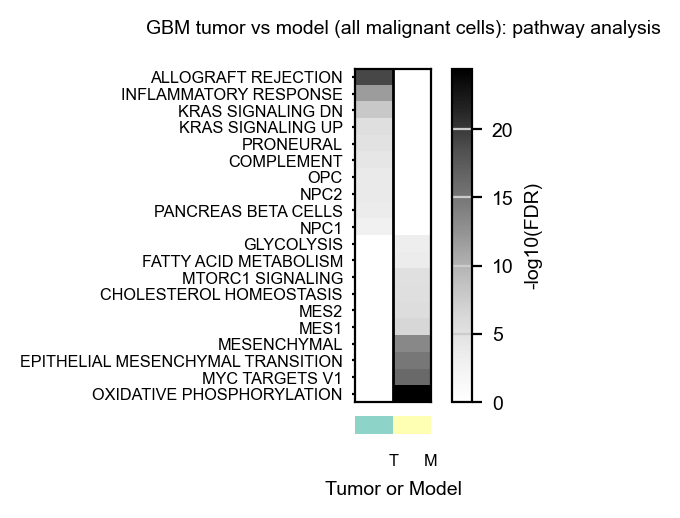

In [16]:
path_enr_DEG.uns["Tumor or Model_colors"] = ['#8dd3c7', '#ffffb3'] # define colormap 


# sort pathways based on NES difference
path_enr_DEG.X = path_enr_DEG.layers["nes"]
diff = path_enr_DEG.to_df()
diff = diff.iloc[0] - diff.iloc[1] # Tumor - Model
sorted_pathways = diff.sort_values(ascending=False)

if only_significant_pathways == True: 
    sorted_pathways = sorted_pathways[sorted_pathways.index.isin(list(significant_pathways))]
        
    sorted_pathways = sorted_pathways.index.tolist() # sorted list of pathways based on Tumor - Model


    if top_pathways == "all":
        pathways_to_show = sorted_pathways
        figsize = (4,9)
    else:
        pathways_to_show = sorted_pathways[:top_pathways] + sorted_pathways[-top_pathways:]
        plt.rcParams.update({
            'font.family': 'Arial',  # Set font family to Arial
            'xtick.labelsize': 7,  # Font size for x-axis labels
            'ytick.labelsize': 7,  # Font size for y-axis labels
            'axes.labelsize': 7,   # Font size for axis labels
            'font.size': 7         # General font size
            })
        figsize = (0.75,top_pathways*0.25)

    # NES
    title = f"{cohort} tumor vs model (all malignant cells): pathway analysis"        
    sc.pl.heatmap(path_enr_DEG, 
                var_names=pathways_to_show, 
                cmap="PuOr_r", 
                var_group_rotation=45,  # Rotation for better label readability
                groupby="Tumor or Model", 
                swap_axes=True, 
                show=False,
                layer = "nes", 
                vcenter=0,
                figsize=figsize)
    plt.suptitle(title, fontsize=7, x=0.5)
    #plt.gca().set_xlabel('')  # Remove the x-axis label
    plt.tight_layout(pad=1.0)  # Add padding to ensure labels are well-placed
    plt.gcf().axes[-1].set_ylabel('NES')  # The colorbar is usually the last axis (-1)
    plt.show()


# -log(FDR)
    title = f"{cohort} tumor vs model (all malignant cells): pathway analysis"        
    sc.pl.heatmap(path_enr_DEG, 
                var_names=pathways_to_show, 
                cmap="Greys", 
                var_group_rotation=45,  # Rotation for better label readability
                layer="mlog10", 
                groupby="Tumor or Model", 
                swap_axes=True, 
                show=False, 
                figsize=figsize)
    plt.suptitle(title, fontsize=7)
    colorbar = plt.gcf().axes[-1]  # The last axis is usually the colorbar
    colorbar.set_ylabel('-log10(FDR)', fontsize=7)
    colorbar.tick_params(labelsize=7)
    plt.tight_layout(pad=1.0)  # Add padding to ensure labels are well-placed
    plt.gcf().axes[-1].set_ylabel('-log10(FDR)')  # The colorbar is usually the last axis (-1)
    plt.show()
